# Compare gpax (viSparseGP) vs BoTorch (SingleTaskGP) on the same data

Side-by-side analysis: feed both backends the **same** single-cell
observations from an existing run, then compare

1. Training-set metrics (R², RMSE, NLPD, coverage, z-score std)
2. Holdout-phase generalisation (refit both without the last phase)
3. ARD lengthscales (which variables each backend deems relevant)
4. Acquisition landscapes (what each backend would pick next)
5. GP-predicted mean landscapes

Preprocessing (classifier + quality gates + per-cell density) runs
ONCE so the two backends see identical data — any difference is
purely the GP + acquisition layer.

In [1]:
import os, glob, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError("haiku removed")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

# ---- User config ----
RUN_PATH = r"E:\Alex\2026-04-10_bo_erk_oscillation_v4_test"
EXP_DATA_PATH = os.path.join(RUN_PATH, "exp_data.parquet")

N_FRAMES_BASELINE = 10
N_FRAMES_STIM = 60
N_FRAMES_RECOVERY = 20
N_FRAMES = N_FRAMES_BASELINE + N_FRAMES_STIM + N_FRAMES_RECOVERY
FIRST_FRAME_STIM = N_FRAMES_BASELINE
LAST_FRAME_STIM = FIRST_FRAME_STIM + N_FRAMES_STIM

CLASSIFIER_PATH = r"./oscillation_model_60min.joblib"
CLASSIFIER_SCRIPT = r"./apply_oscillation_classifier_v2.py"

N_CONDITIONS_PER_ITER = 2
N_INITIAL_PHASES = 2

In [2]:
import joblib

model_data = joblib.load(CLASSIFIER_PATH)
osc_clf = model_data["clf"]
osc_scaler = model_data["scaler"]
osc_feature_cols = model_data["feature_cols"]
osc_cfg = model_data["config"]
osc_cfg["window_size"] = model_data["window_size"]
osc_cfg["window_step"] = model_data["window_step"]

_spec = importlib.util.spec_from_file_location("osc_clf_mod", CLASSIFIER_SCRIPT)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
predict_trace = _mod.predict_trace

df_exp = pd.read_parquet(EXP_DATA_PATH)
cond_map_df = (
    df_exp.groupby(["phase_id", "fov"])
    .agg(stim_exposure=("stim_exposure", "first"), ramp=("ramp", "first"))
    .reset_index()
)
phases = sorted(df_exp["phase_id"].unique())
print(
    f"Loaded {len(df_exp)} rows, {len(phases)} phases, {df_exp['fov'].nunique()} FOVs"
)

Loaded 688761 rows, 9 phases, 162 FOVs


## Preprocess once (shared between backends)

Runs the single-cell classifier + quality gates + density computation
across every phase.  Both backends will train on the result.

In [3]:
from faro.agents.bo_optimization import BO_Parameter, BO_Objective, BO_Covariate
from faro.agents.bo_oscillation_single_cell import OscillationBOSingleCell

bo_params = [
    BO_Parameter(name="stim_exposure", bounds=(50.0, 500.0), spacing=25.0),
    BO_Parameter(name="ramp", bounds=(0.0, 20.0), spacing=5.0),
]

bo_covariates = [
    BO_Covariate(name="baseline_cnr"),
    BO_Covariate(name="optortk_expression"),
    BO_Covariate(name="mean_dist_k_nearest"),
]
bo_objective = BO_Objective(name="mean_osc_probability", goal="maximize")

common_kwargs = dict(
    n_frames=N_FRAMES,
    first_frame_stim=FIRST_FRAME_STIM,
    last_frame_stim=LAST_FRAME_STIM,
    time_between_timesteps=60,
    imaging_channels=(),
    stim_channel=None,
    optocheck_channel=None,
    osc_clf=osc_clf,
    osc_scaler=osc_scaler,
    osc_feature_cols=osc_feature_cols,
    osc_cfg=osc_cfg,
    osc_predict_fn=predict_trace,
    min_osc_probability=0.0,
    min_consecutive_windows=0,
    min_fft_amplitude=0.0,
    n_baseline_frames=N_FRAMES_BASELINE,
    density_k_neighbours=5,
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=len(phases),
    n_conditions_per_iter=N_CONDITIONS_PER_ITER,
    n_initial_phases=N_INITIAL_PHASES,
    acquisition_function="ei",
    n_cov_samples=20,
    ei_xi=0.2,
    ei_xi_final=0.01,
    ei_xi_decay_fraction=0.7,
    plot_live=False,
    save_checkpoints=False,
    verbose=False,
)

# Use a throwaway gpax-sparse agent just to run preprocessing
_pre_agent = OscillationBOSingleCell(
    storage_path=os.path.join(RUN_PATH, "replay_compare_pre"),
    gp_backend="vi_sparse",
    inducing_points_ratio=0.1,
    num_svi_steps=10,
    svi_step_size=5e-3,
    gp_batch_size=2000,
    **common_kwargs,
)
os.makedirs(_pre_agent.storage_path, exist_ok=True)
_pre_agent._ensure_results_df()

all_cells = []
for phase_id in phases:
    df_phase_raw = df_exp[df_exp["phase_id"] == phase_id]
    fov_tracks = {
        int(fov): df_phase_raw[df_phase_raw["fov"] == fov].copy()
        for fov in df_phase_raw["fov"].unique()
    }
    cm = cond_map_df[cond_map_df["phase_id"] == phase_id]
    _pre_agent._current_condition_map = {
        int(row["fov"]): dict(
            stim_exposure=float(row["stim_exposure"]), ramp=float(row["ramp"])
        )
        for _, row in cm.iterrows()
    }
    _pre_agent._current_phase_id = int(phase_id)
    df_new = _pre_agent._preprocess_results(fov_tracks)
    if not df_new.empty:
        all_cells.append(df_new)

df_cells = pd.concat(all_cells, ignore_index=True)
print(
    f"Preprocessed {len(df_cells)} cells across {df_cells['phase_id'].nunique()} phases"
)
print(df_cells.head())

  Phase 0: 655 cells (from 18 FOVs), mean mean_osc_probability=0.1092, max=0.9960
  Phase 1: 285 cells (from 17 FOVs), mean mean_osc_probability=0.1577, max=0.9805
  Phase 2: 677 cells (from 18 FOVs), mean mean_osc_probability=0.1794, max=0.9969
  Phase 3: 435 cells (from 18 FOVs), mean mean_osc_probability=0.2145, max=0.9926
  Phase 4: 409 cells (from 18 FOVs), mean mean_osc_probability=0.2393, max=0.9976
  Phase 5: 551 cells (from 18 FOVs), mean mean_osc_probability=0.1955, max=0.9980
  Phase 6: 444 cells (from 18 FOVs), mean mean_osc_probability=0.2820, max=0.9901
  Phase 7: 508 cells (from 18 FOVs), mean mean_osc_probability=0.1835, max=0.9977
  Phase 8: 503 cells (from 18 FOVs), mean mean_osc_probability=0.1991, max=0.9808
Preprocessed 4467 cells across 9 phases
   stim_exposure  ramp  baseline_cnr  optortk_expression  mean_dist_k_nearest  \
0           75.0  15.0      0.359169         1244.718447           134.170438   
1           75.0  15.0      0.673951         1827.733813    

## Fit both backends on the full dataset

In [4]:
from faro.agents.bo_oscillation_single_cell_botorch import (
    OscillationBOSingleCellBoTorch,
)

# gpax sparse
agent_gp = OscillationBOSingleCell(
    storage_path=os.path.join(RUN_PATH, "replay_compare_gpax"),
    gp_backend="vi_sparse",
    inducing_points_ratio=0.1,
    num_svi_steps=1500,
    svi_step_size=5e-3,
    gp_batch_size=2000,
    **common_kwargs,
)
os.makedirs(agent_gp.storage_path, exist_ok=True)
agent_gp.df_results = df_cells.copy()

# BoTorch
agent_bt = OscillationBOSingleCellBoTorch(
    storage_path=os.path.join(RUN_PATH, "replay_compare_botorch"),
    **common_kwargs,
)
os.makedirs(agent_bt.storage_path, exist_ok=True)
agent_bt.df_results = df_cells.copy()

print("Fitting gpax viSparseGP...")
agent_gp.iteration = len(phases) - 1
agent_gp._last_plot_context = None
params_gp = agent_gp._determine_next_parameters(agent_gp.df_results, verbose=False)

print("\nFitting BoTorch SingleTaskGP...")
agent_bt.iteration = len(phases) - 1
agent_bt._last_plot_context = None
params_bt = agent_bt._determine_next_parameters(agent_bt.df_results, verbose=False)

print(f"\nNext pick — gpax:    {params_gp}")
print(f"Next pick — BoTorch: {params_bt}")

Fitting gpax viSparseGP...
  Fitting vi_sparse on 4467 observations (5-D)...
  ARD lengthscales (small = highly relevant):
    stim_exposure                 lengthscale= 0.136
    ramp                          lengthscale= 0.507
    baseline_cnr                  lengthscale= 4.171
    optortk_expression            lengthscale= 0.364
    mean_dist_k_nearest           lengthscale= 2.959
    k_scale=0.212   noise=0.808
  Predicting 1900 points (95 grid x 20 cov samples)...

Fitting BoTorch SingleTaskGP...
  Fitting SingleTaskGP on 4467 observations (5-D)...
  Predicting 1900 points (95 grid x 20 cov samples)...

Next pick — gpax:    {'stim_exposure': np.float64(175.0), 'ramp': np.float64(20.0)}
Next pick — BoTorch: {'stim_exposure': np.float64(175.0), 'ramp': np.float64(20.0)}


## ARD lengthscales side-by-side

Small = high relevance.  Sanity check: do both backends agree on which
variables matter?

dim                             gpax ls      bt ls    gpax rel    bt rel
--------------------------------------------------------------------------------
stim_exposure                     0.136      0.291         1.00      0.09
ramp                              0.507      0.644         0.27      0.04
baseline_cnr                      4.171      1.803         0.03      0.01
optortk_expression                0.364      0.025         0.37      1.00
mean_dist_k_nearest               2.959      0.405         0.05      0.06


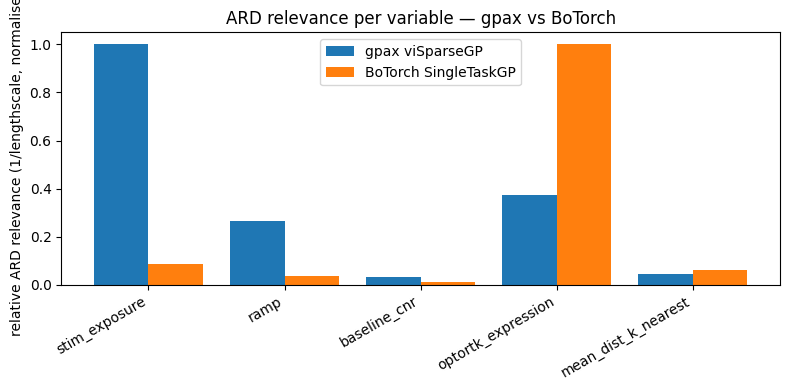

In [5]:
import torch

dim_names = [p.name for p in agent_gp.parameters_to_optimize] + [
    c.name for c in agent_gp.bo_covariates
]

# gpax
ls_gp = np.asarray(agent_gp.model.get_samples()["k_length"]).squeeze()

# BoTorch
cm = agent_bt.model.covar_module
kernel = getattr(cm, "base_kernel", cm)
ls_bt = kernel.lengthscale.detach().cpu().numpy().squeeze()

# Relative relevance (normalised per-backend; only within-backend ranking is meaningful)
rel_gp = 1.0 / ls_gp
rel_gp /= rel_gp.max()
rel_bt = 1.0 / ls_bt
rel_bt /= rel_bt.max()

print(
    f"{'dim':28s}  {'gpax ls':>9s}  {'bt ls':>9s}    {'gpax rel':>8s}  {'bt rel':>8s}"
)
print("-" * 80)
for name, a, b, ra, rb in zip(dim_names, ls_gp, ls_bt, rel_gp, rel_bt):
    print(
        f"{name:28s}  {float(a):9.3f}  {float(b):9.3f}     {float(ra):8.2f}  {float(rb):8.2f}"
    )

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(dim_names))
w = 0.4
ax.bar(x - w / 2, rel_gp, w, label="gpax viSparseGP")
ax.bar(x + w / 2, rel_bt, w, label="BoTorch SingleTaskGP")
ax.set_xticks(x)
ax.set_xticklabels(dim_names, rotation=30, ha="right")
ax.set_ylabel("relative ARD relevance (1/lengthscale, normalised)")
ax.set_title("ARD relevance per variable — gpax vs BoTorch")
ax.legend()
plt.tight_layout()
plt.show()

## Training-set fit metrics side-by-side

In [10]:
from faro.agents.bo_optimization_sparse import _safe_batch_size


def _predict(agent, X_raw, use_botorch):
    if use_botorch:
        x_transformed = agent._apply_log_transforms(X_raw)
        Xp = torch.tensor(x_transformed, dtype=torch.double)
        with torch.no_grad():
            post = agent.model.posterior(Xp)
            mean = post.mean.squeeze(-1).numpy()
            var = post.variance.squeeze(-1).numpy()
        if agent.objective_metric.log_scale:
            mean = np.exp(mean)
            var = var * (mean**2)
        return mean, np.sqrt(np.maximum(var, 1e-12))

    X_scaled = np.asarray(agent._x_scaler.transform(X_raw))
    _bs = _safe_batch_size(X_scaled.shape[0], agent.gp_batch_size)
    mean_s, var_s = agent.model.predict_in_batches(
        agent._rng_key_predict,
        X_scaled,
        batch_size=_bs,
        noiseless=True,
    )
    mean_s = np.asarray(mean_s).flatten()
    var_s = np.asarray(var_s).flatten()
    mean = agent._y_scaler.inverse_transform(mean_s.reshape(-1, 1)).flatten()
    y_std_scale = float(np.abs(np.asarray(agent._y_scaler.std_)[0]))
    return mean, np.sqrt(np.maximum(var_s, 1e-12)) * y_std_scale


def _metrics(agent, df, use_botorch):
    cols = [p.name for p in agent.parameters_to_optimize] + [
        c.name for c in agent.bo_covariates
    ]
    y = df[agent.objective_metric.name].to_numpy(dtype=float)
    X = df[cols].to_numpy(dtype=float)
    m, s = _predict(agent, X, use_botorch)
    resid = y - m
    r2 = 1 - float(np.sum(resid**2)) / max(float(np.sum((y - y.mean()) ** 2)), 1e-12)
    rmse = float(np.sqrt(np.mean(resid**2)))
    nlpd = float(np.mean(0.5 * np.log(2 * np.pi * s**2) + 0.5 * (resid**2) / (s**2)))
    cov = float(np.mean((y >= m - 1.96 * s) & (y <= m + 1.96 * s)))
    z_std = float(np.std(resid / np.maximum(s, 1e-12)))
    return dict(
        r2=r2, rmse=rmse, nlpd=nlpd, coverage=cov, z_std=z_std, mean=m, std=s, y=y
    )


train_gp = _metrics(agent_gp, df_cells, use_botorch=False)
train_bt = _metrics(agent_bt, df_cells, use_botorch=True)

summary = pd.DataFrame(
    {
        "gpax viSparseGP": [
            train_gp[k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")
        ],
        "BoTorch SingleTaskGP": [
            train_bt[k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")
        ],
    },
    index=["R²", "RMSE", "NLPD (lower=better)", "95% coverage", "z-score std"],
)
print(summary.round(4))
print(f"(target y std = {df_cells[bo_objective.name].std():.4f})")

                     gpax viSparseGP  BoTorch SingleTaskGP
R²                            0.1727                0.1230
RMSE                          0.2412                0.2483
NLPD (lower=better)          28.1331              152.9426
95% coverage                  0.3049                0.1636
z-score std                   7.8094               17.6653
(target y std = 0.2652)


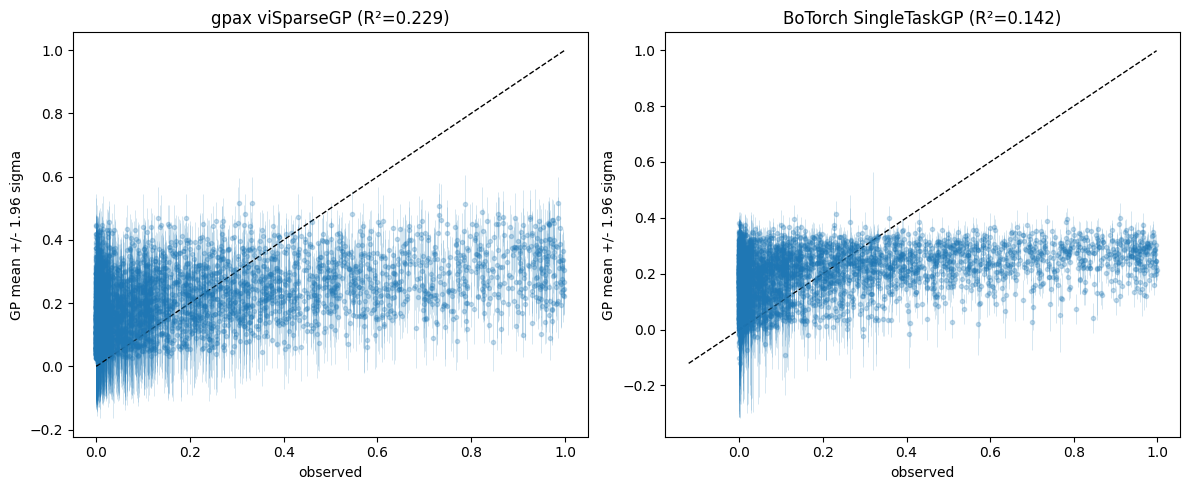

In [7]:
# Predicted vs observed, side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (diag, name) in zip(
    axes, [(train_gp, "gpax viSparseGP"), (train_bt, "BoTorch SingleTaskGP")]
):
    ax.errorbar(
        diag["y"],
        diag["mean"],
        yerr=1.96 * diag["std"],
        fmt="o",
        alpha=0.25,
        ms=3,
        lw=0.5,
    )
    lo = min(diag["y"].min(), diag["mean"].min())
    hi = max(diag["y"].max(), diag["mean"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    r2 = 1 - np.sum((diag["y"] - diag["mean"]) ** 2) / np.sum(
        (diag["y"] - diag["y"].mean()) ** 2
    )
    ax.set_title(f"{name} (R²={r2:.3f})")
    ax.set_xlabel("observed")
    ax.set_ylabel("GP mean +/- 1.96 sigma")
plt.tight_layout()
plt.show()

## Holdout phase: honest generalisation

Drop the last phase, refit both backends, predict the held-out cells.
This is the fair comparison — anything that looks great on training
alone might be overfitting.

Holdout phase 8: train n=3964, test n=503
  Fitting vi_sparse on 3964 observations (5-D)...
  ARD lengthscales (small = highly relevant):
    stim_exposure                 lengthscale= 0.900
    ramp                          lengthscale= 0.760
    baseline_cnr                  lengthscale= 3.342
    optortk_expression            lengthscale= 0.349
    mean_dist_k_nearest           lengthscale= 3.047
    k_scale=0.172   noise=0.837
  Predicting 1860 points (93 grid x 20 cov samples)...
  Fitting SingleTaskGP on 3964 observations (5-D)...
  Predicting 1860 points (93 grid x 20 cov samples)...

=== Holdout phase metrics ===
              gpax viSparseGP  BoTorch SingleTaskGP
R²                     0.0564                0.0649
RMSE                   0.2654                0.2642
NLPD                  32.9627              219.1853
95% coverage           0.2147                0.1173
z-score std            8.3704               21.0567


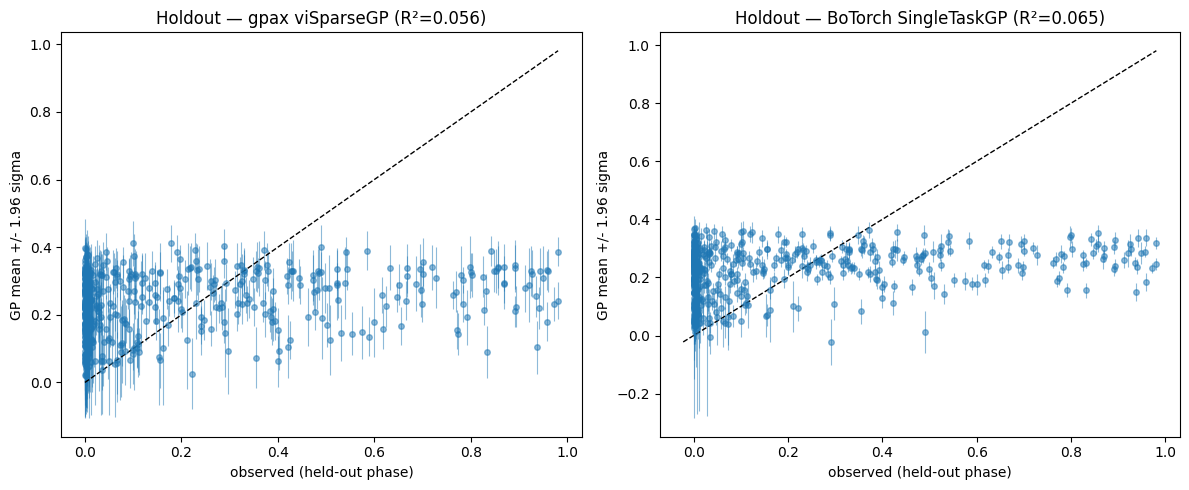

In [11]:
HOLDOUT_PHASE = max(phases)
df_train = df_cells[df_cells["phase_id"] != HOLDOUT_PHASE]
df_test = df_cells[df_cells["phase_id"] == HOLDOUT_PHASE]

print(f"Holdout phase {HOLDOUT_PHASE}: train n={len(df_train)}, test n={len(df_test)}")

agent_gp.df_results = df_train.copy()
agent_gp._last_plot_context = None
_ = agent_gp._determine_next_parameters(df_train, verbose=False)

agent_bt.df_results = df_train.copy()
agent_bt._last_plot_context = None
_ = agent_bt._determine_next_parameters(df_train, verbose=False)

holdout_gp = _metrics(agent_gp, df_test, use_botorch=False)
holdout_bt = _metrics(agent_bt, df_test, use_botorch=True)

summary_h = pd.DataFrame(
    {
        "gpax viSparseGP": [
            holdout_gp[k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")
        ],
        "BoTorch SingleTaskGP": [
            holdout_bt[k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")
        ],
    },
    index=["R²", "RMSE", "NLPD", "95% coverage", "z-score std"],
)
print("\n=== Holdout phase metrics ===")
print(summary_h.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (diag, name) in zip(
    axes, [(holdout_gp, "gpax viSparseGP"), (holdout_bt, "BoTorch SingleTaskGP")]
):
    ax.errorbar(
        diag["y"],
        diag["mean"],
        yerr=1.96 * diag["std"],
        fmt="o",
        alpha=0.5,
        ms=4,
        lw=0.8,
    )
    lo = min(diag["y"].min(), diag["mean"].min())
    hi = max(diag["y"].max(), diag["mean"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    r2 = 1 - np.sum((diag["y"] - diag["mean"]) ** 2) / np.sum(
        (diag["y"] - diag["y"].mean()) ** 2
    )
    ax.set_title(f"Holdout — {name} (R²={r2:.3f})")
    ax.set_xlabel("observed (held-out phase)")
    ax.set_ylabel("GP mean +/- 1.96 sigma")
plt.tight_layout()
plt.show()

## GP-predicted landscapes side-by-side

Using the full-data fits (not holdout).  Rebuild `agent.df_results`
first and refit on the full set so the landscape reflects all
observations.

  Fitting vi_sparse on 4467 observations (5-D)...
  ARD lengthscales (small = highly relevant):
    stim_exposure                 lengthscale= 0.136
    ramp                          lengthscale= 0.507
    baseline_cnr                  lengthscale= 4.171
    optortk_expression            lengthscale= 0.364
    mean_dist_k_nearest           lengthscale= 2.959
    k_scale=0.212   noise=0.808
  Predicting 1840 points (92 grid x 20 cov samples)...
  Fitting SingleTaskGP on 4467 observations (5-D)...
  Predicting 1840 points (92 grid x 20 cov samples)...


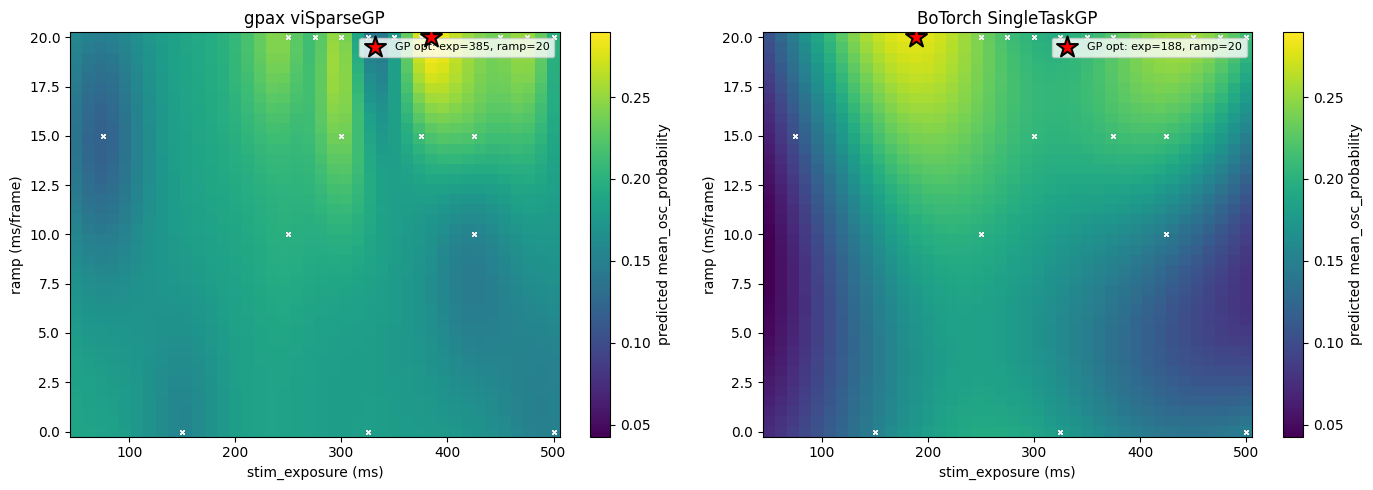

In [12]:
# Refit on FULL dataset so landscapes use everything
agent_gp.df_results = df_cells.copy()
agent_gp._last_plot_context = None
_ = agent_gp._determine_next_parameters(df_cells, verbose=False)
agent_bt.df_results = df_cells.copy()
agent_bt._last_plot_context = None
_ = agent_bt._determine_next_parameters(df_cells, verbose=False)

# Shared grid
grid_n = 40
x0_vals = np.linspace(50.0, 500.0, grid_n)
x1_vals = np.linspace(0.0, 20.0, grid_n)
X0, X1 = np.meshgrid(x0_vals, x1_vals, indexing="ij")
ctrl_grid = np.column_stack([X0.ravel(), X1.ravel()])

# Joint cov samples from df_cells
cov_cols = [c.name for c in bo_covariates]
cov_vals = df_cells[cov_cols].to_numpy(dtype=float)
rng = np.random.default_rng(0)
n_mc = 50
cov_samples = cov_vals[rng.integers(0, cov_vals.shape[0], size=n_mc)]
x_full = np.hstack(
    [np.repeat(ctrl_grid, n_mc, axis=0), np.tile(cov_samples, (ctrl_grid.shape[0], 1))]
)

mean_gp, _ = _predict(agent_gp, x_full, use_botorch=False)
mean_bt, _ = _predict(agent_bt, x_full, use_botorch=True)

Z_gp = mean_gp.reshape(ctrl_grid.shape[0], n_mc).mean(axis=1).reshape(grid_n, grid_n)
Z_bt = mean_bt.reshape(ctrl_grid.shape[0], n_mc).mean(axis=1).reshape(grid_n, grid_n)

vmin = min(Z_gp.min(), Z_bt.min())
vmax = max(Z_gp.max(), Z_bt.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Z, name in zip(axes, [Z_gp, Z_bt], ["gpax viSparseGP", "BoTorch SingleTaskGP"]):
    im = ax.pcolormesh(X0, X1, Z, cmap="viridis", shading="auto", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, label="predicted mean_osc_probability")
    ax.scatter(
        df_cells["stim_exposure"],
        df_cells["ramp"],
        c="white",
        s=8,
        alpha=0.3,
        marker="x",
        linewidths=0.5,
    )
    opt_i = int(np.argmax(Z))
    ax.scatter(
        X0.ravel()[opt_i],
        X1.ravel()[opt_i],
        c="red",
        s=250,
        marker="*",
        edgecolors="black",
        linewidths=1.5,
        zorder=10,
        label=f"GP opt: exp={X0.ravel()[opt_i]:.0f}, ramp={X1.ravel()[opt_i]:.0f}",
    )
    ax.legend(loc="upper right", fontsize=8)
    ax.set_xlabel("stim_exposure (ms)")
    ax.set_ylabel("ramp (ms/frame)")
    ax.set_title(f"{name}")
plt.tight_layout()
plt.show()

## Acquisition landscapes side-by-side

Uses the pre-computed `acq_values_total` stashed by each backend.

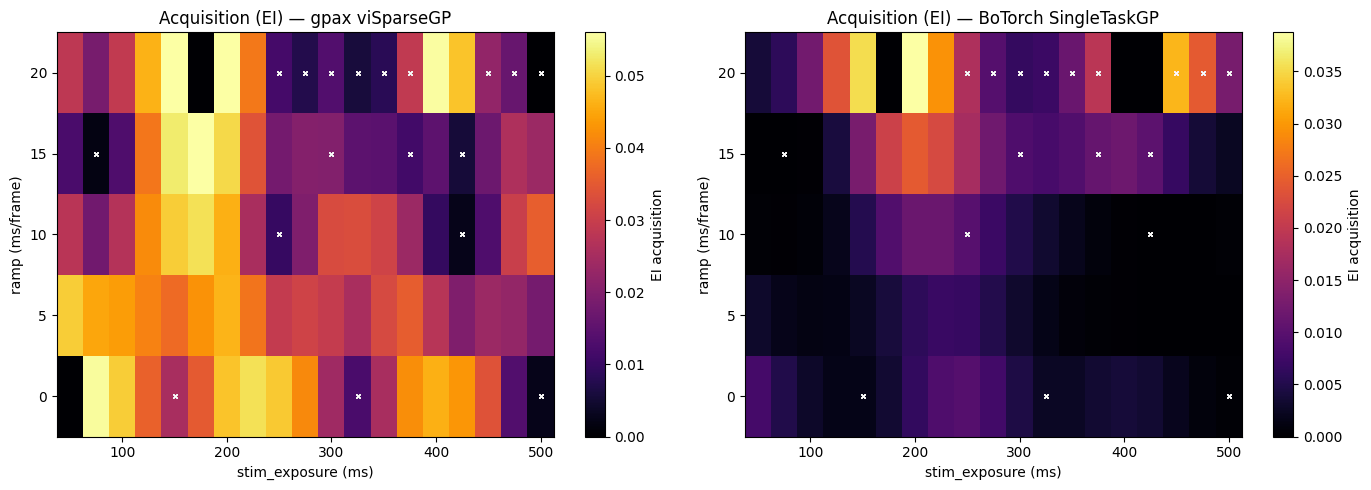

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, agent_, backend_name in [
    (axes[0], agent_gp, "gpax viSparseGP"),
    (axes[1], agent_bt, "BoTorch SingleTaskGP"),
]:
    ctx = agent_._last_plot_context
    if ctx is None:
        ax.text(0.5, 0.5, "no plot context", ha="center", transform=ax.transAxes)
        continue
    acq = np.asarray(ctx["acq_values_total"])
    xu = ctx["x_unmeasured_at_computation"]
    x_total = agent_.x_total_linespace.copy()
    u1 = np.unique(x_total[:, 0])
    u2 = np.unique(x_total[:, 1])
    n_ctrl = len(u1) * len(u2)
    if len(acq) != n_ctrl:
        acq_full = np.zeros(n_ctrl)
        for j, pt in enumerate(xu):
            idx = int(np.argmin(np.abs(x_total - pt).sum(axis=1)))
            if j < len(acq):
                acq_full[idx] = float(acq[j])
        acq = acq_full
    acq_2d = acq.reshape(len(u1), len(u2))
    Xm, Ym = np.meshgrid(u1, u2, indexing="ij")
    im = ax.pcolormesh(Xm, Ym, acq_2d, cmap="inferno", shading="auto")
    fig.colorbar(im, ax=ax, label="EI acquisition")
    ax.scatter(
        df_cells["stim_exposure"],
        df_cells["ramp"],
        c="white",
        s=8,
        alpha=0.3,
        marker="x",
        linewidths=0.5,
    )
    ax.set_xlabel("stim_exposure (ms)")
    ax.set_ylabel("ramp (ms/frame)")
    ax.set_title(f"Acquisition (EI) — {backend_name}")
plt.tight_layout()
plt.show()